In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="2"
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import trees

# test correctness

data reached node [1 1 2 1 2 2 2 2 2 1 1 2 1 2 1 1 1 2 2 2 2 1 2 2 1 1 2 1 1 2 1 2]


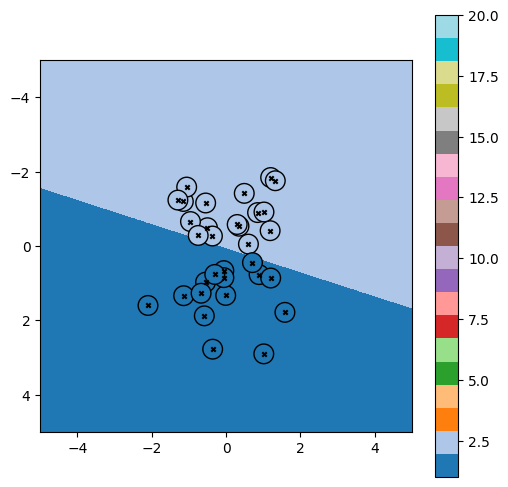

data reached node [4 3 5 3 5 5 5 5 5 4 4 5 3 5 3 4 4 6 6 6 5 4 5 5 4 3 5 3 4 5 4 5]


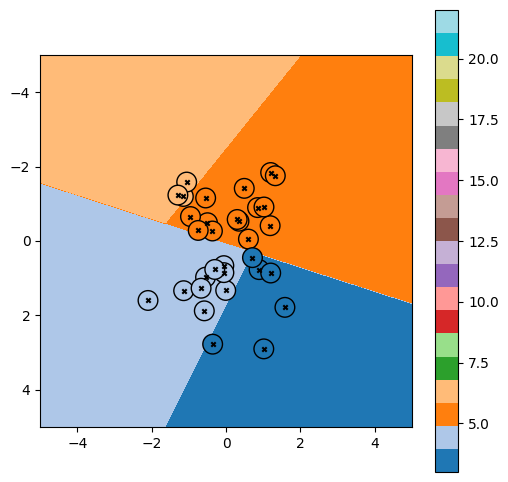

data reached node [10  7 11  7 11 11 12 11 12 10  9 11  8 11  7 10 10 13 14 14 11 10 11 11
  9  8 11  7 10 11 10 11]


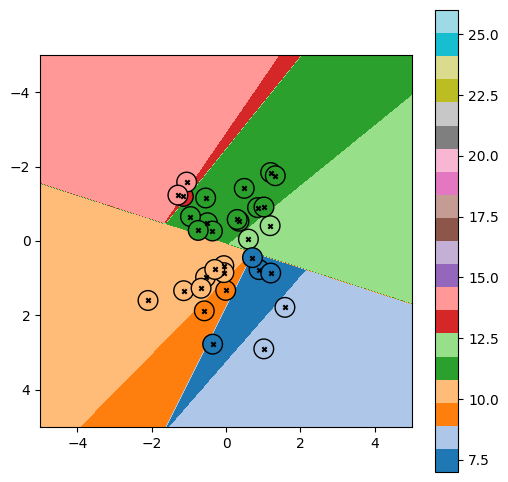

data reached node [22 16 23 16 23 23 26 23 25 22 19 23 17 24 15 21 21 27 30 29 23 22 23 23
 20 18 23 16 22 23 22 23]


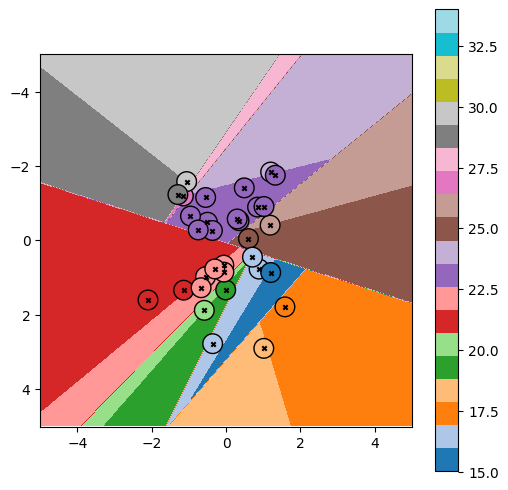

In [4]:
n_components = 2
rng = jax.random.PRNGKey(42)
data = jax.random.normal(rng, (32, 2))
tree_nodes = trees.make_tree(rng, data, n_components)

batch_path = jax.vmap(trees.path, in_axes=(0, None))
X, Y = jnp.meshgrid(jnp.linspace(-5, 5, 1000), jnp.linspace(-5, 5, 1000))
coord = jnp.stack([X.flatten(), Y.flatten()]).T
data_paths = batch_path(data, tree_nodes)
region_paths = batch_path(coord, tree_nodes)

for depth, (data_path_ids, region_paths_ids) in enumerate(
    zip(data_paths[:, 1:].T, region_paths[:, 1:].T)
):
    print(f"data reached node {data_path_ids}")
    plt.figure(figsize=(6, 6))
    # scatter data color coded by region
    plt.scatter(
        data[:, 0],
        data[:, 1],
        s=200,
        c=data_path_ids,
        cmap="tab20",
        edgecolors="k",
        vmin=region_paths_ids.min(),
        vmax=region_paths_ids.min() + 19,
    )
    plt.scatter(data[:, 0], data[:, 1], marker="x", c="k", s=10)
    # imshow node regions
    plt.imshow(
        region_paths_ids.reshape(1000, 1000),
        cmap="tab20",
        vmin=region_paths_ids.min(),
        vmax=region_paths_ids.min() + 19,
        extent=(-5, 5, 5, -5),
    )
    plt.colorbar()
    plt.show()

In [5]:
from functools import partial
@partial(jax.jit, static_argnums=(2,3,4))
def make_forest(rng, data, subsample_size, n_trees, n_components):
    rng_split, rng_forest = jax.random.split(rng)
    rng_trees = jax.random.split(rng_forest, n_trees)
    # split data into subsamples
    data = data[jax.random.randint(rng_split, (n_trees, subsample_size), 0, data.shape[0])]
    print(data.shape)
    return jax.vmap(trees.make_tree, in_axes=(0,0,None))(rng_trees, data, n_components)

(256, 128, 2)


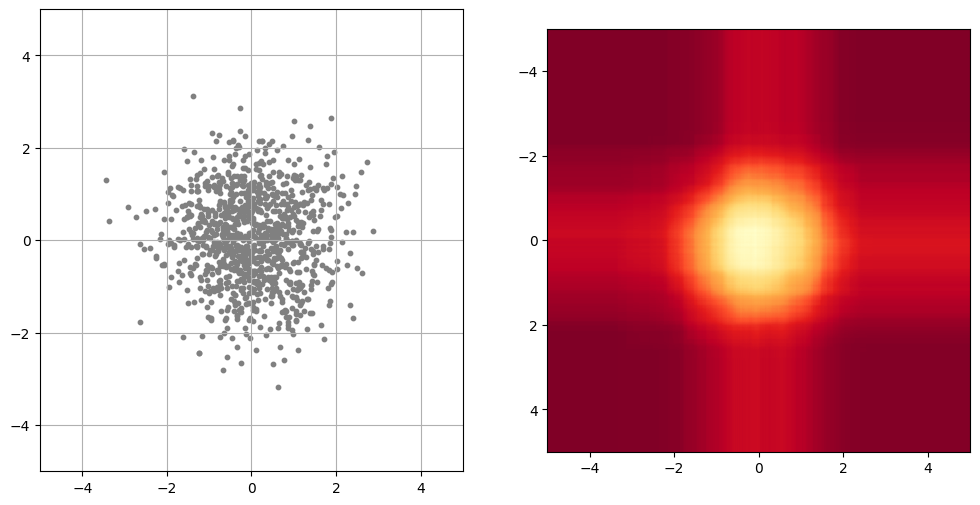

In [45]:
n_trees = 256
subsample_size = 128
n_components = 1

rng_data, rng_forest = jax.random.split(jax.random.PRNGKey(42))
data = jax.random.normal(rng_data, (1024, 2))
forest_nodes = make_forest(rng_forest, data, subsample_size, n_trees, n_components)


batched_forest_paths = jax.vmap(batch_path, in_axes=(None, 0))
X, Y = jnp.meshgrid(jnp.linspace(-5, 5, 1000), jnp.linspace(-5, 5, 1000))
coord = jnp.stack([X.flatten(), Y.flatten()]).T
data_paths = batched_forest_paths(data, forest_nodes)
region_paths = batched_forest_paths(coord, forest_nodes)

leaf_sizes = jnp.take_along_axis(forest_nodes.node_sizes, region_paths[:, :, -1], axis=-1)
# imshow node regions
plt.figure(figsize=(12, 6))
plt.subplot(122)
plt.imshow(-leaf_sizes.mean(axis=0).reshape(1000, 1000), extent=(-5, 5, 5, -5), cmap="YlOrRd")
plt.subplot(121)
plt.scatter(data[:, 0], data[:, 1], marker="o", c="grey", s=10)
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.grid()
plt.show()

# Test speed

In [4]:
n_trees = 128
subsample_size = 256
n_dim = 16
n_components = 1

In [5]:
rng_data, rng_forest = jax.random.split(jax.random.PRNGKey(42))
data = jax.random.normal(rng_data, (10000, n_dim))
tree_nodes = make_forest(rng_forest, data, subsample_size, n_trees, n_components)
print(f"data: {data.shape}, reached: {tree_nodes.node_sizes.shape}")
print(f"normals: {tree_nodes.normals.shape}, intercepts: {tree_nodes.intercepts.shape}")
%timeit make_forest(rng_forest, data, subsample_size, n_trees, n_components)

(128, 256, 16)
data: (10000, 16), reached: (128, 511)
normals: (128, 511, 16), intercepts: (128, 511)
1.06 ms ± 1.32 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [6]:
from sklearn.ensemble import IsolationForest
import numpy as np
data = np.random.normal(size=(10000, n_dim))
print(data.shape)
model = IsolationForest(
    n_estimators=n_trees,
    max_samples=subsample_size,
)
%timeit model.fit(data)

(10000, 16)
102 ms ± 845 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
